<a href="https://colab.research.google.com/github/readytocommit/DeepLearning--MIT-Series/blob/main/word_embedding_mit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Stand-alone word embeddings


In [3]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#Set the seed

keras.utils.set_random_seed(42)

In [53]:
def plot_loss_curves(history):
  plt.clf()
  hist_dict = history.history
  loss_val = hist_dict['loss']
  val_loss_val = hist_dict['val_loss']
  epoches = range(1,len(loss_val)+1)
  plt.plot(epoches,loss_val,"bo",label="Train Loss")
  plt.plot(epoches,val_loss_val,"b",label = "Validation Loss")
  plt.xlabel("Epoches")
  plt.ylabel("Losses")
  plt.title("Training and Validation Loss")
  plt.legend()
  plt.show()


In [61]:
def plot_accuracy(history):
  plt.clf()
  history_dict = history.history
  acc = history_dict['accuracy']
  val_acc = history_dict['val_accuracy']
  epoches = range(1,len(acc)+1)
  plt.plot(epoches,acc,"bo",label= "Train Accuracy")
  plt.plot(epoches,val_acc,"b", label = "Validation Accuracy")
  plt.xlabel("Epoches")
  plt.ylabel("Accuracy")
  plt.title("Training and Validation Accuracy")
  plt.legend()
  plt.show()

In [6]:

#Retrieving and Preparing the Data

train_url = "https://www.dropbox.com/scl/fi/ito6bnl2yaf1uw0uqibzf/lyric_genre_train.csv?rlkey=04dkn5un2djza8x0bdmfnlw3u&st=y47qh8i4&dl=1"
val_url = "https://www.dropbox.com/scl/fi/xmywjzqsaa8n5sn1bs0t9/lyric_genre_val.csv?rlkey=hggbeo0s1iaxjpa6z80429xl9&st=6i7d8eau&dl=1"
test_url = "https://www.dropbox.com/scl/fi/fnocl69w9ojs9s5zb0xvf/lyric_genre_test.csv?rlkey=z4hjopw7vaihoh948cbb5mvdp&st=xwond7dp&dl=1"

train_df = pd.read_csv(train_url, index_col=0).astype(str)
validation_df = pd.read_csv(val_url, index_col=0).astype(str)
test_df = pd.read_csv(test_url, index_col=0).astype(str)

In [7]:
print(f"""

Train Samples: {train_df.shape[0]}
Validation Samples : {validation_df.shape[0]}
Test Samples : {test_df.shape[0]}

""")



Train Samples: 48991
Validation Samples : 16331
Test Samples : 21774




In [11]:
#Using pre-trained embedding as-is

# We can learn word embeddings from our data, or we can insert previously trained embeddings into our model.

# Let's now take the second route and use already trained word embeddings. This can be useful if you don't have enough data to learn a task-specific embedding in your
# vocabulary.


# It has the drawback that this embedding will not be customized to your data, but they capture generic aspects of language structure. This is not necessarily bad since one would
# expect that in most cases word features to be fairly generic.

# There are couple of popular word embeddings that you can download and use in Keras Embedding layer (Word2Vec, GloVe). GloVe was pretrained on the 2014 English Wikipedia dataset.


In [9]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

--2026-04-27 08:58:54--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-04-27 08:58:55--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-04-27 08:58:55--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [10]:
#Unzip the file
!unzip -q glove.6B.zip

In [11]:
#Look at the first line of the raw file

! head -1 /content/glove.6B.100d.txt

the -0.038194 -0.24487 0.72812 -0.39961 0.083172 0.043953 -0.39141 0.3344 -0.57545 0.087459 0.28787 -0.06731 0.30906 -0.26384 -0.13231 -0.20757 0.33395 -0.33848 -0.31743 -0.48336 0.1464 -0.37304 0.34577 0.052041 0.44946 -0.46971 0.02628 -0.54155 -0.15518 -0.14107 -0.039722 0.28277 0.14393 0.23464 -0.31021 0.086173 0.20397 0.52624 0.17164 -0.082378 -0.71787 -0.41531 0.20335 -0.12763 0.41367 0.55187 0.57908 -0.33477 -0.36559 -0.54857 -0.062892 0.26584 0.30205 0.99775 -0.80481 -3.0243 0.01254 -0.36942 2.2167 0.72201 -0.24978 0.92136 0.034514 0.46745 1.1079 -0.19358 -0.074575 0.23353 -0.052062 -0.22044 0.057162 -0.15806 -0.30798 -0.41625 0.37972 0.15006 -0.53212 -0.2055 -1.2526 0.071624 0.70565 0.49744 -0.42063 0.26148 -1.538 -0.30223 -0.073438 -0.28312 0.37104 -0.25217 0.016215 -0.017099 -0.38984 0.87424 -0.72569 -0.51058 -0.52028 -0.1459 0.8278 0.27062


In [12]:
embedding_dim = 100
path_to_glove_file = f"glove.6B.{embedding_dim}d.txt"

embedding_index = {}

with open(path_to_glove_file) as f:
  for line in f:
    word ,coefs = line.split(maxsplit=1)
    coefs = np.fromstring(coefs,"f",sep = " ")
    embedding_index[word] = coefs

print(f"Found {len(embedding_index)} word vectors")


Found 400000 word vectors


In [13]:
#Lets look at some word vectors.

embedding_index['movie']

array([ 0.38251  ,  0.14821  ,  0.60601  , -0.51533  ,  0.43992  ,
        0.061053 , -0.62716  , -0.025385 ,  0.1643   , -0.22101  ,
        0.14423  , -0.37213  , -0.21683  , -0.08895  ,  0.097904 ,
        0.6561   ,  0.64455  ,  0.47698  ,  0.83849  ,  1.6486   ,
        0.88922  , -0.1181   , -0.012465 , -0.52082  ,  0.77854  ,
        0.48723  , -0.014991 , -0.14127  , -0.34747  , -0.29595  ,
        0.1028   ,  0.57191  , -0.045594 ,  0.026443 ,  0.53816  ,
        0.32257  ,  0.40788  , -0.043599 , -0.146    , -0.48346  ,
        0.32036  ,  0.55086  , -0.76259  ,  0.43269  ,  0.61753  ,
       -0.36503  , -0.60599  , -0.79615  ,  0.3929   , -0.23668  ,
       -0.34719  , -0.61201  ,  0.54747  ,  0.94812  ,  0.20941  ,
       -2.7771   , -0.6022   ,  0.8495   ,  1.2549   ,  0.017893 ,
       -0.041901 ,  2.1147   , -0.026618 , -0.28104  ,  0.68124  ,
       -0.14165  ,  0.99249  ,  0.49879  , -0.67538  ,  0.6417   ,
        0.42303  , -0.27913  ,  0.063403 ,  0.68909  , -0.3618

In [14]:
#Let's now load the GloVe embeddings into the model and train it !

# First we will set up the TextVectorization and Embedding layers.

max_length = 300
max_tokens = 5000

text_vectorization = keras.layers.TextVectorization(
    max_tokens = max_tokens,
    output_mode = 'int',
    output_sequence_length = max_length
)

In [1]:
#Sentences in our dataset will be of different lengths and we want to convert them to the same length.
# We usually choose a length that's big enough to accomodate the majority of sentences. This is the output_sentence_length arguement.
# Sentence shorter then output_sequence_length are padded to zeros. Sentencecs longer than output_sequence_length are truncated

In [15]:
#Now let's run the training corpus through the TextVectorization layer to create the vocabulary.

text_vectorization.adapt(train_df['Lyric'])

In [16]:
text_vectorization.get_vocabulary()[:20]

['',
 '[UNK]',
 np.str_('the'),
 np.str_('you'),
 np.str_('i'),
 np.str_('to'),
 np.str_('and'),
 np.str_('a'),
 np.str_('me'),
 np.str_('it'),
 np.str_('my'),
 np.str_('in'),
 np.str_('im'),
 np.str_('on'),
 np.str_('your'),
 np.str_('that'),
 np.str_('of'),
 np.str_('all'),
 np.str_('be'),
 np.str_('is')]

In [17]:
#Important: When output_mode = int, the vocabulary will use index 0 for the empty string "" and 1 for UNK. Empty string is a PAD. Since the index 0
# is used to 'pad' short sentences to max_length.


In [18]:
text_vectorization(["HODL, you are the best !"]) # all zeros you are padding

<tf.Tensor: shape=(1, 300), dtype=int64, numpy=
array([[  1,   3,  58,   2, 258,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
   

In [19]:
X_train = text_vectorization(train_df['Lyric'])
X_val = text_vectorization(validation_df['Lyric'])
X_test = text_vectorization(test_df['Lyric'])

In [20]:
#Next Embedding layer

# We first create a matrix from the GloVe embeddings we downloaded. This matric will be used to initialize the Embedding layer.


vocabulary = text_vectorization.get_vocabulary()

In [25]:
word_index = dict(zip(vocabulary, range(len(vocabulary))))

In [36]:
# creates a lookup table that maps integers to the corresponding word vectors


counter = 0
embedding_matrix = np.zeros((max_tokens,embedding_dim))
for word, i in word_index.items():
  if i < max_tokens:
    embedding_vector = embedding_index.get(word)
  if embedding_vector is not None:
    embedding_matrix[i] = embedding_vector
  else:
    counter += 1



In [37]:
embedding_matrix.shape # the first 5000 max choosen vocabs

(5000, 100)

In [42]:
# The first two rows should be all zeros since they correspond to PAD and UNK

embedding_matrix[:3,:]

array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0. 

In [43]:
# Next we will set up the embedding layers.

embedding_layer = keras.layers.Embedding(
    max_tokens,
    embedding_dim,
    embeddings_initializer = keras.initializers.Constant(embedding_matrix),
    trainable = False,
    mask_zero = True
)

#Since we want to use the downloaded GLoVE embeddings, we have initialized the Embedding layer with the matrix we built earlier.

# Like any other weights, the weights of an Embedding layers (it's iternal dictionary of token vectors) will get gradually adjusted via gradient
# descent (i.e backprop) during training. But for starters, we want to keep them unchanged. So we add an extra arguement trainable = False to freeze
# the layer to avoid disrupting these pretrained GLoVE embeddings during training.

# mask_zero = True later..

In [45]:
#set up the NN-model

inputs = keras.Input(shape= (max_length,))
embedded = embedding_layer(inputs) #300 x 100 table comes out
embedded = keras.layers.GlobalAveragePooling1D()(embedded) #100 - element vector
x = keras.layers.Dense(8,activation="relu")(embedded) #only hidden layer
outputs = keras.layers.Dense(3,activation="softmax")(x) #output layer

model = keras.Model(inputs,outputs)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 100)  │    500,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 300)       │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 100)       │          0 │ embedding[1][0],  │
│ (GlobalAveragePool… │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │        808 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │         27 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 500,835 (1.91 MB)

 Trainable params: 835 (3.26 KB)

 Non-trainable params: 500,000 (1.91 MB)

In [46]:
#Let's take a look at the first few embedding vectors.

emb = model.layers[1]
emb.weights

[<Variable path=embedding/embeddings, shape=(5000, 100), dtype=float32, value=[[ 0.        0.        0.       ...  0.        0.        0.      ]
  [ 0.        0.        0.       ...  0.        0.        0.      ]
  [-0.038194 -0.24487   0.72812  ... -0.1459    0.8278    0.27062 ]
  ...
  [ 0.33947   0.16186   0.083984 ... -0.66934  -0.073064  0.91467 ]
  [-0.09169   0.10361   0.23232  ... -0.13697  -0.81738   0.3868  ]
  [ 0.28468  -0.26489   0.1649   ... -0.6158   -0.10085   1.0357  ]]>]

In [48]:
#Notice that the first two vectors are all zeros. They correspond to the PAD and UNK tokens (equivalently index 0 and 1) respectively. The other
# vectors are all from GloVe.

model.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy",
    metrics = ['accuracy']
)

In [49]:
y_train = pd.get_dummies(train_df['Genre']).to_numpy()
y_val = pd.get_dummies(validation_df['Genre']).to_numpy()
y_test = pd.get_dummies(test_df['Genre']).to_numpy()

print(y_test.shape)

(21774, 3)


In [51]:
history = model.fit(
    x = X_train,
    y = y_train,
    validation_data = (X_val,y_val),
    epochs = 10,
    batch_size = 32
)

Epoch 1/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.5543 - loss: 0.9104 - val_accuracy: 0.5704 - val_loss: 0.8665
Epoch 2/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5925 - loss: 0.8463 - val_accuracy: 0.5960 - val_loss: 0.8316
Epoch 3/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6103 - loss: 0.8214 - val_accuracy: 0.6115 - val_loss: 0.8131
Epoch 4/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6194 - loss: 0.8072 - val_accuracy: 0.6185 - val_loss: 0.8028
Epoch 5/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6253 - loss: 0.7980 - val_accuracy: 0.6262 - val_loss: 0.7947
Epoch 6/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6291 - loss: 0.7914 - val_accuracy: 0.6306 - val_loss: 0.7881
Epoch 7/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6330 - loss: 0.7863 - val_accuracy: 0.6355 - val_loss: 0.7826
Epoch 8/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6357 - loss: 0.7823 - 

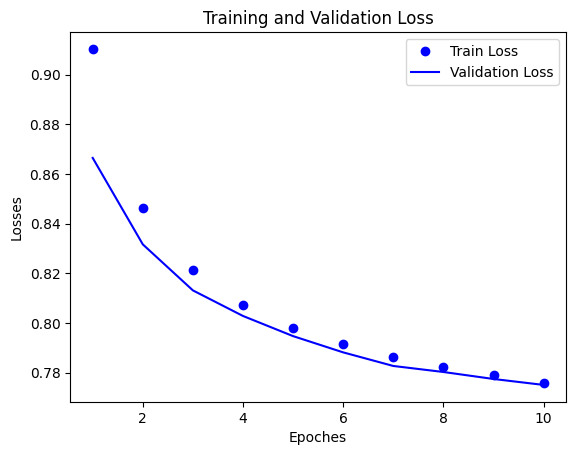

In [54]:
plot_loss_curves(history)

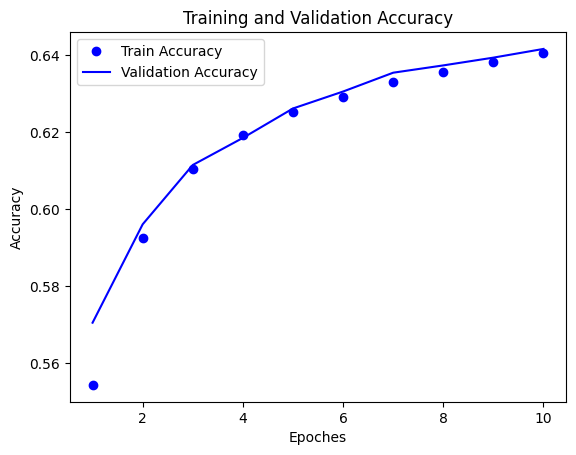

In [62]:
plot_accuracy(history)